<div style="border-left: 6px solid #00cfff; 
background: linear-gradient(90deg, #0f2027, #203a43); 
padding: 20px; 
color: #b3f5ff; 
font-size: 40px; 
font-family: 'Segoe UI', sans-serif; 
font-weight: 400; 
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<b style="color: #00cfff;">⚡</b> 
<span style="color: #ffffff;">Exercícios Aprendizado Produnfo</span>
</div>

<div style="border-left: 6px solid #00cfff; 
background: linear-gradient(90deg, #0f2027, #203a43); 
padding: 20px; 
color: #b3f5ff; 
font-size: 22px; 
font-family: 'Segoe UI', sans-serif; 
font-weight: 300; 
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">1) Implemente uma rede perceptron de múltiplas camadas e utilize-a para aproximar as funções abaixo.</span>
</div>

In [1]:
# Importação das bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

<div style="border-left: 6px solid #00cfff; 
background: linear-gradient(90deg, #0f2027, #203a43); 
padding: 20px; 
color: #b3f5ff; 
font-size: 18px; 
font-family: 'Segoe UI', sans-serif; 
font-weight: 300; 
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">Funções</span>
</div>

### $a) f(x) = sin(2x)+cos(3x), onde 0 ≤ x ≤ 5$
### $b) f(x) = 10x^5+ 5x^4+ 2x^3– 0.5x^2+ 3x + 2, \text(onde) 0 ≤ x ≤ 5$

<div style="border-left: 6px solid #00cfff; 
background: linear-gradient(90deg, #0f2027, #203a43); 
padding: 20px; 
color: #b3f5ff; 
font-size: 18px; 
font-family: 'Segoe UI', sans-serif; 
font-weight: 300; 
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">Função A</span>
</div>

In [3]:
# =========================
# Função (a): f(x) = sin(2x) + cos(3x)
# =========================

x = np.linspace(0, 5, 800).reshape(-1, 1)
y = np.sin(2*x) + np.cos(3*x)

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [9]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train_s = scaler_x.fit_transform(x_train)
x_test_s = scaler_x.transform(x_test)

y_train_s = scaler_y.fit_transform(y_train)
y_test_s = scaler_y.transform(y_test)

<div style="border-left: 6px solid #00cfff; 
background: linear-gradient(90deg, #0f2027, #203a43); 
padding: 20px; 
color: #b3f5ff; 
font-size: 18px; 
font-family: 'Segoe UI', sans-serif; 
font-weight: 300; 
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">Implementação de uma Multilayer Perceptron (MLP)</span>
</div>

In [11]:
mlp_a = MLPRegressor(
    hidden_layer_sizes=(100, 100, 50),
    activation='tanh',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1500,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=20,
    random_state=42
)

In [13]:
mlp_a.fit(x_train_s, y_train_s.ravel())

MLPRegressor(activation='tanh', early_stopping=True,
             hidden_layer_sizes=(100, 100, 50), max_iter=1500,
             n_iter_no_change=20, random_state=42, validation_fraction=0.2)

In [15]:
# Predições
y_pred_train = scaler_y.inverse_transform(
    mlp_a.predict(x_train_s).reshape(-1, 1)
)
y_pred_test = scaler_y.inverse_transform(
    mlp_a.predict(x_test_s).reshape(-1, 1)
)
y_pred = scaler_y.inverse_transform(
    mlp_a.predict(scaler_x.transform(x)).reshape(-1, 1)
)

In [17]:
# MSE
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"Função (a) - MSE Treino: {mse_train:.6f}")
print(f"Função (a) - MSE Teste: {mse_test:.6f}")

Função (a) - MSE Treino: 0.002151
Função (a) - MSE Teste: 0.002407


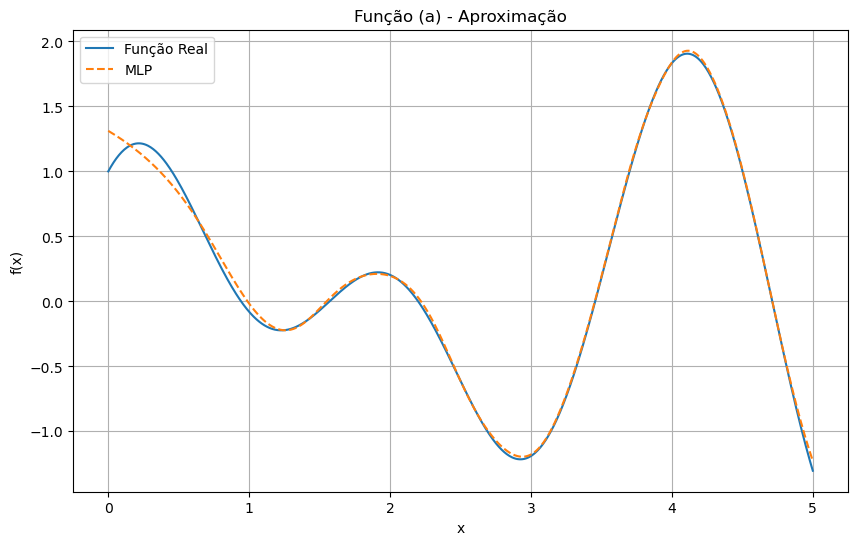

In [19]:
# ===== Gráfico Aproximação (a) =====
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Função Real')
plt.plot(x, y_pred, '--', label='MLP')
plt.legend()
plt.title("Função (a) - Aproximação")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

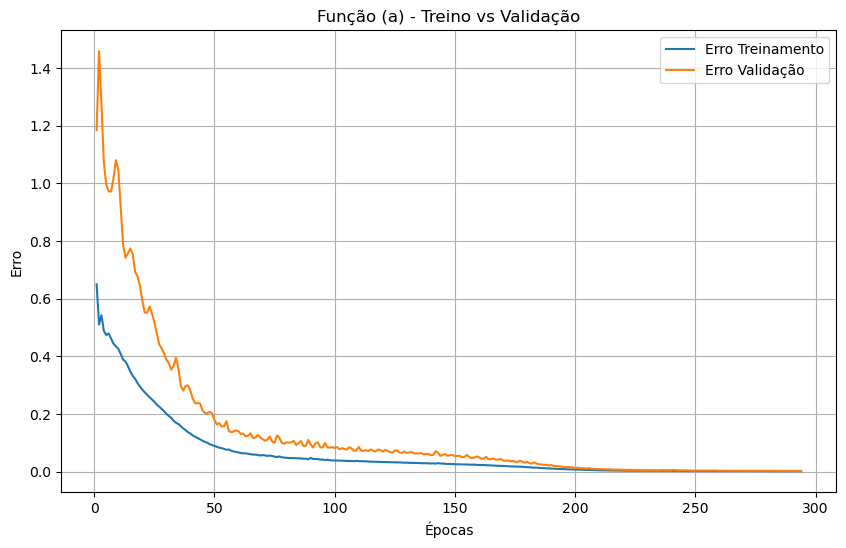

In [21]:
# ===== Curvas de erro (a) =====
epochs_a = range(1, len(mlp_a.loss_curve_) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_a, mlp_a.loss_curve_, label='Erro Treinamento')
plt.plot(epochs_a, 1 - np.array(mlp_a.validation_scores_),
         label='Erro Validação')
plt.title("Função (a) - Treino vs Validação")
plt.xlabel("Épocas")
plt.ylabel("Erro")
plt.legend()
plt.grid(True)
plt.show()

<div style="border-left: 6px solid #00cfff; 
background: linear-gradient(90deg, #0f2027, #203a43); 
padding: 20px; 
color: #b3f5ff; 
font-size: 18px; 
font-family: 'Segoe UI', sans-serif; 
font-weight: 300; 
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">Função B</span>
</div>

In [25]:
x2 = np.linspace(0, 5, 800).reshape(-1, 1)
y2_original = 10*x2**5 + 5*x2**4 + 2*x2**3 - 0.5*x2**2 + 3*x2 + 2

# Transformação log
y2_log = np.log1p(y2_original)

In [27]:
x2_train, x2_test, y2_train_log, y2_test_log = train_test_split(
    x2, y2_log, test_size=0.3, random_state=42
)

In [29]:
scaler_x2 = StandardScaler()

x2_train_s = scaler_x2.fit_transform(x2_train)
x2_test_s = scaler_x2.transform(x2_test)

In [31]:
mlp_b = MLPRegressor(
    hidden_layer_sizes=(150, 150),
    activation='tanh',
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)

mlp_b.fit(x2_train_s, y2_train_log.ravel())

MLPRegressor(activation='tanh', hidden_layer_sizes=(150, 150), max_iter=5000,
             random_state=42, solver='lbfgs')

In [33]:
# Predição
y2_pred_log = mlp_b.predict(scaler_x2.transform(x2))
y2_pred = np.expm1(y2_pred_log).reshape(-1, 1)

y2_pred_train = np.expm1(
    mlp_b.predict(x2_train_s)
).reshape(-1, 1)

y2_pred_test = np.expm1(
    mlp_b.predict(x2_test_s)
).reshape(-1, 1)

y2_train_original = np.expm1(y2_train_log).reshape(-1, 1)
y2_test_original = np.expm1(y2_test_log).reshape(-1, 1)

In [35]:
# MSE
mse2_train = mean_squared_error(y2_train_original, y2_pred_train)
mse2_test = mean_squared_error(y2_test_original, y2_pred_test)

print(f"\nFunção (b) - MSE Treino (escala real): {mse2_train:.6f}")
print(f"Função (b) - MSE Teste (escala real): {mse2_test:.6f}")


Função (b) - MSE Treino (escala real): 242.377032
Função (b) - MSE Teste (escala real): 310.577654


In [37]:
# Erro percentual
erro_percentual = np.mean(
    np.abs((y2_test_original - y2_pred_test) / y2_test_original)
) * 100

print(f"Erro Percentual Médio: {erro_percentual:.4f}%")

Erro Percentual Médio: 0.1947%


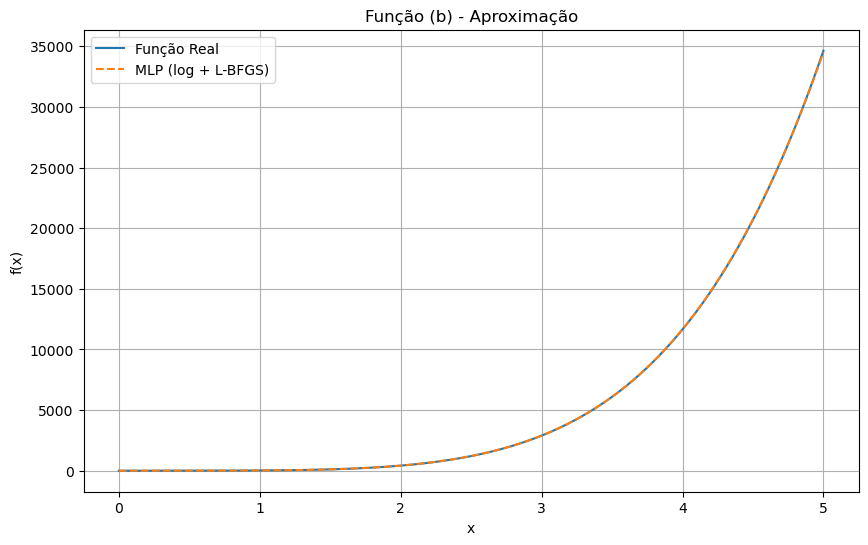

In [39]:
# ===== Gráfico Aproximação (b) =====
plt.figure(figsize=(10, 6))
plt.plot(x2, y2_original, label='Função Real')
plt.plot(x2, y2_pred, '--', label='MLP (log + L-BFGS)')
plt.legend()
plt.title("Função (b) - Aproximação")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()